# Breast Cancer Prediction - Professional End-to-End Machine Learning Project

This notebook follows an industry-style workflow:

1. Data Loading and Inspection
2. Data Cleaning and Leakage Checks
3. Exploratory Data Analysis (EDA)
4. Correlation and Feature Relationships
5. Outlier Analysis (Medical-data aware approach)
6. Train-Test Split
7. Preprocessing Pipeline
8. Multiple Model Comparison
9. Overfitting Detection
10. Automatic Best Model Selection
11. Hyperparameter Tuning
12. Final Evaluation
13. Model Saving and Prediction Function


In [4]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import joblib


In [5]:
# Load Data
# If this line gives an error, replace with:
# df = pd.read_excel('data (1).xls')

df = pd.read_csv('data.csv')
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
# Basic Information
print('Shape:', df.shape)
display(df.info())
display(df.describe().T)


Shape: (569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter

None

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [7]:
# Missing Values and Duplicates
display(df.isnull().sum())
print('Duplicate Rows:', df.duplicated().sum())


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

Duplicate Rows: 0


In [8]:
# Remove leakage-prone / unnecessary columns
cols_to_drop = [c for c in ['id', 'Unnamed: 32'] if c in df.columns]
df = df.drop(columns=cols_to_drop)
print('Dropped:', cols_to_drop)


Dropped: ['id', 'Unnamed: 32']


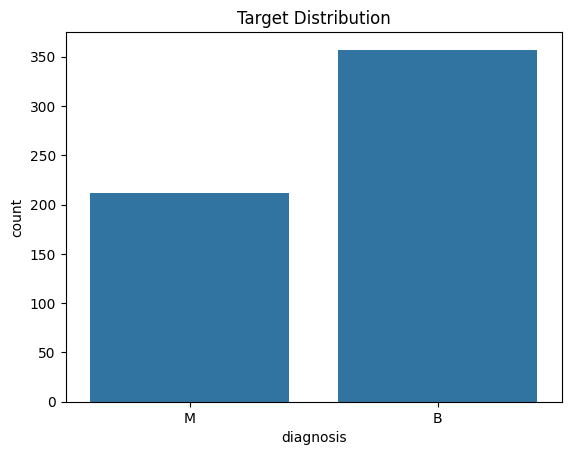

In [9]:
# Target Distribution
if 'diagnosis' in df.columns:
    sns.countplot(data=df, x='diagnosis')
    plt.title('Target Distribution')
    plt.show()


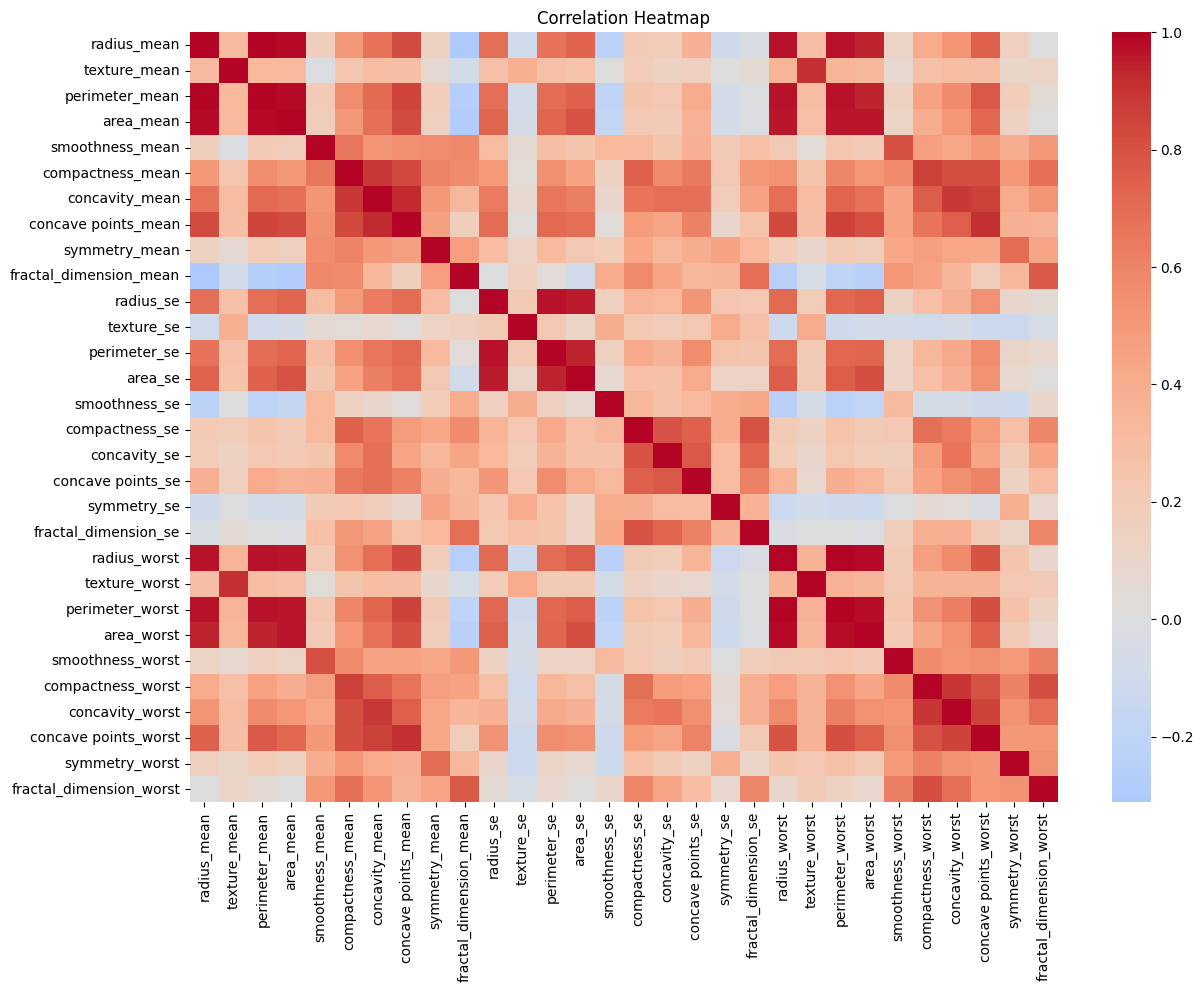

In [10]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


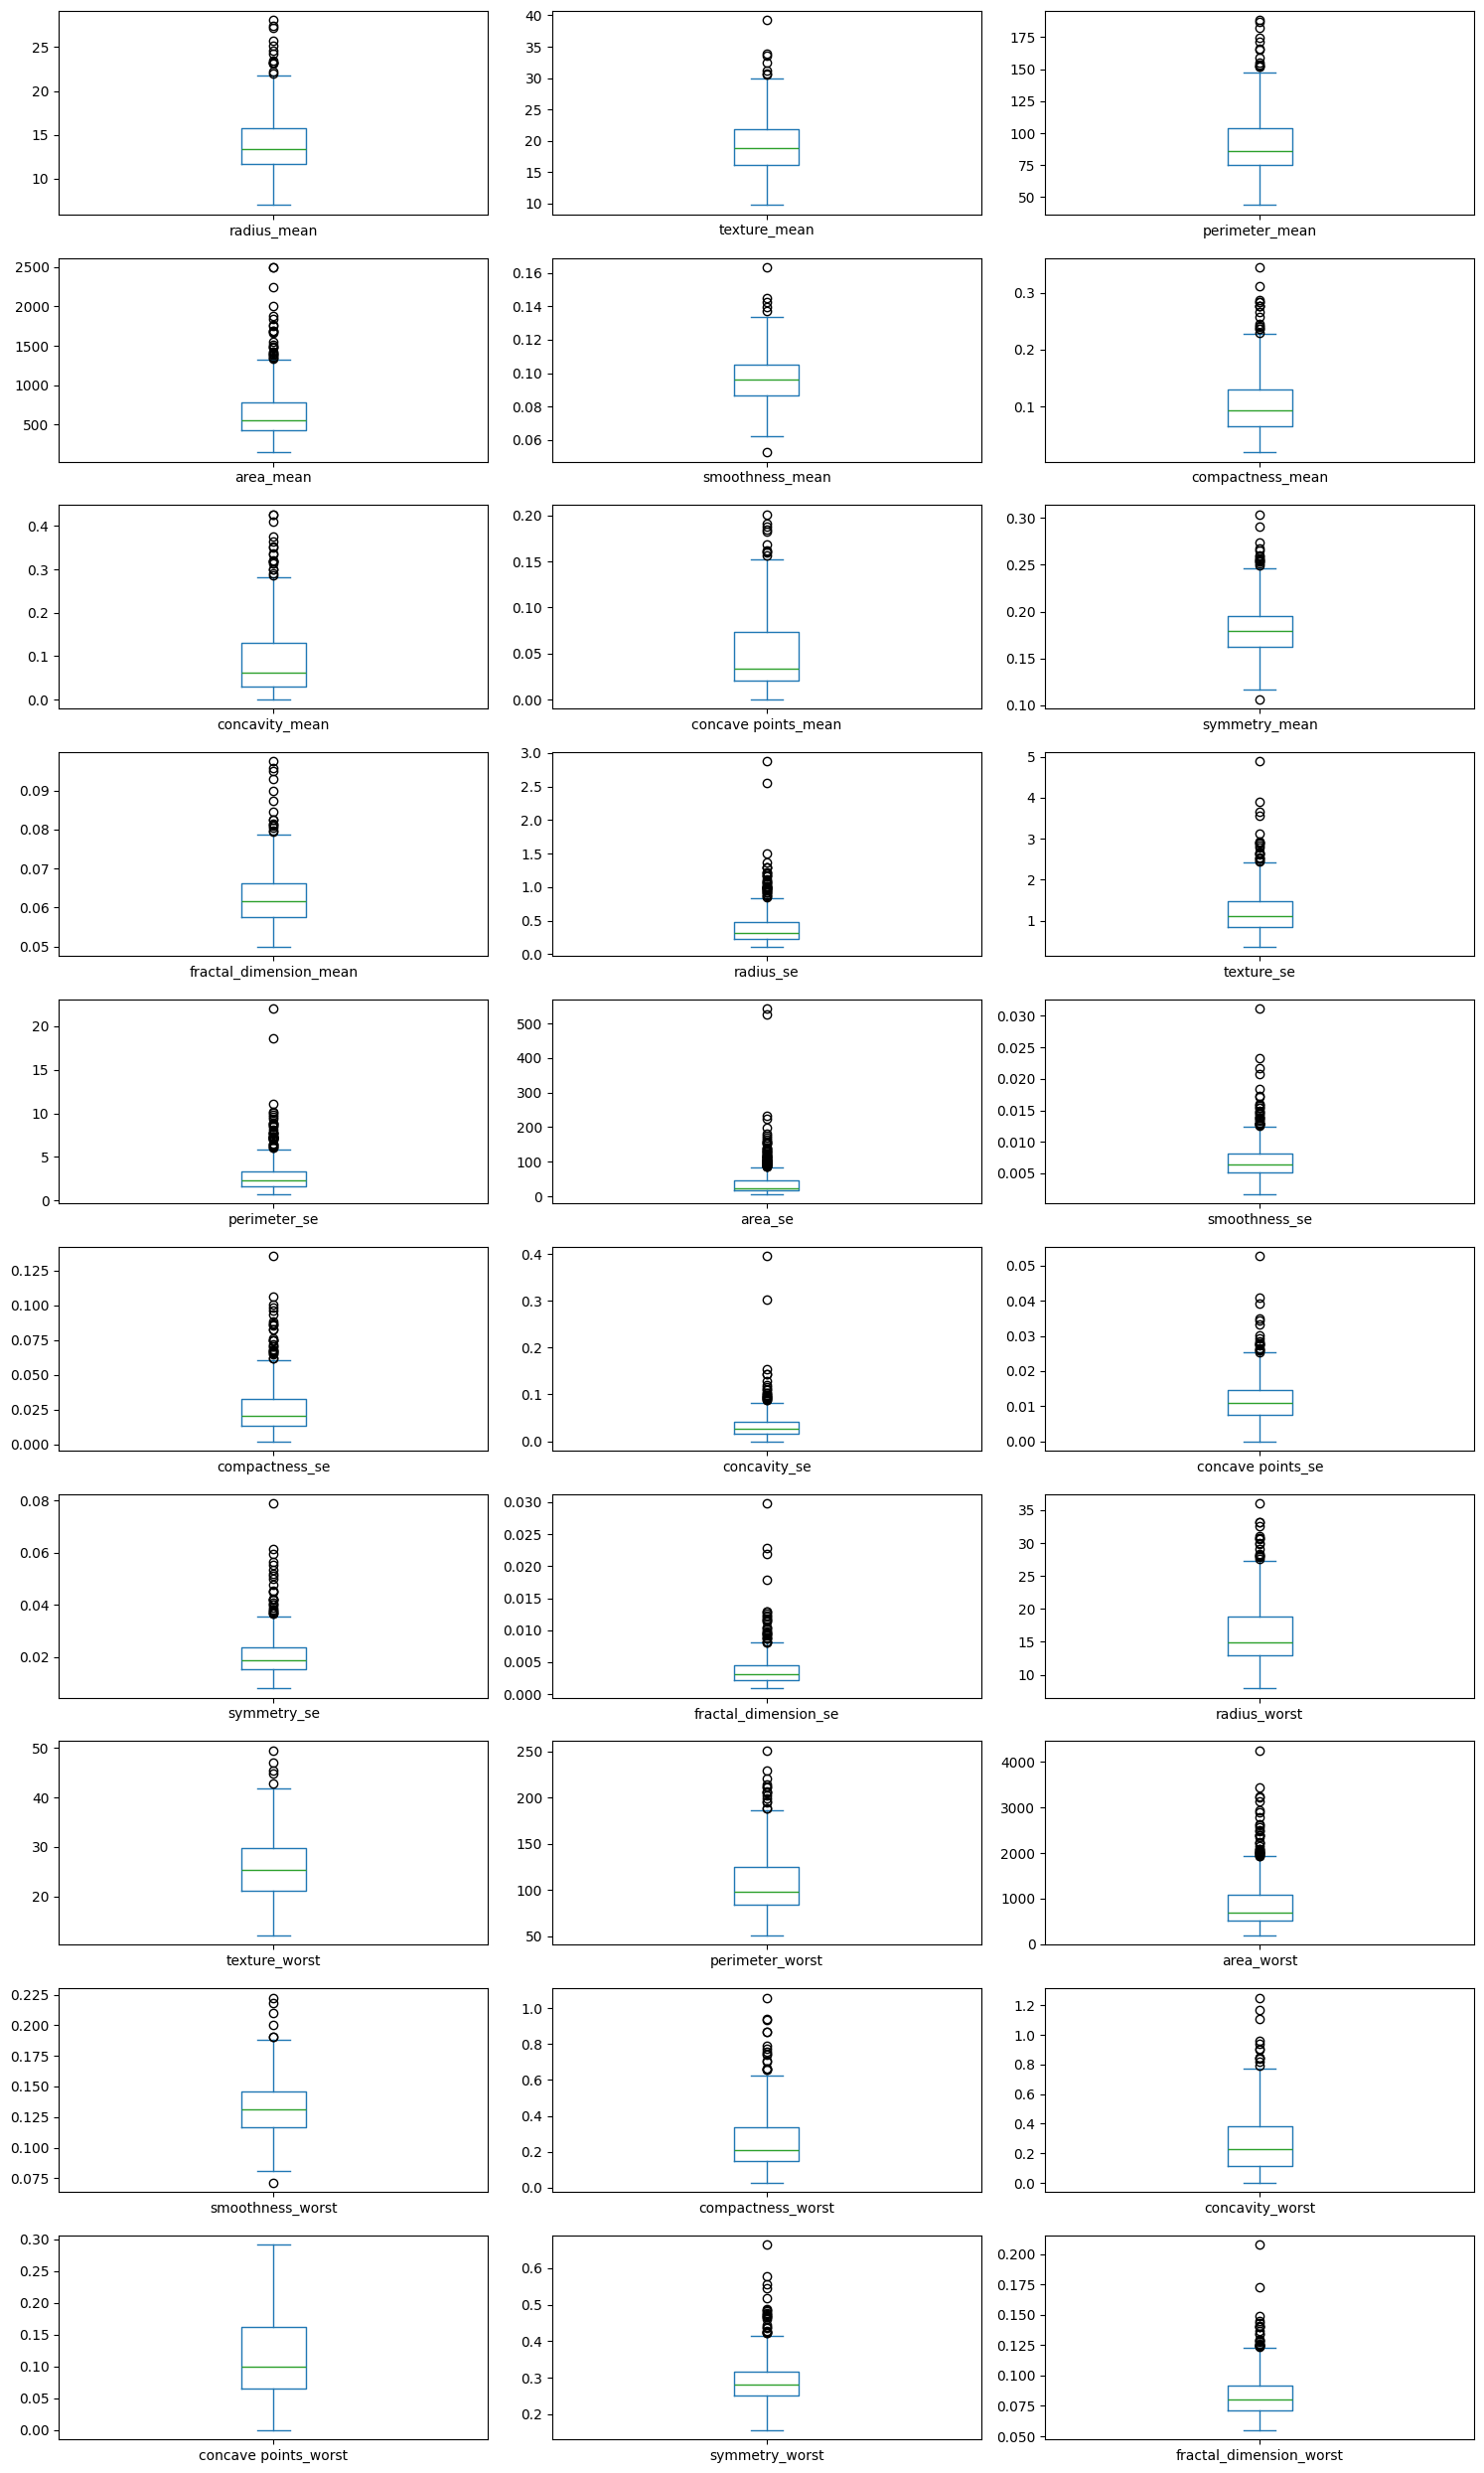

In [11]:
# Outlier Inspection (Do not aggressively remove in medical data)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].plot(kind='box', subplots=True,
                      layout=(int(np.ceil(len(numeric_cols)/3)),3),
                      figsize=(15,25))
plt.tight_layout()
plt.show()


In [12]:
# Prepare Features and Target
if df['diagnosis'].dtype == 'object':
    df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [13]:
# Preprocessing Pipeline
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler', StandardScaler())
         ]),
         numeric_features)
    ]
)


In [14]:
# Multiple Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    cv = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc'
    )

    results.append({
        'Model': name,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'CV_ROC_AUC': cv.mean(),
        'Overfitting_Gap': train_acc - test_acc
    })

results_df = pd.DataFrame(results).sort_values(
    by='CV_ROC_AUC',
    ascending=False
)

display(results_df)


,Model,Train_Accuracy,Test_Accuracy,CV_ROC_AUC,Overfitting_Gap
0,Logistic Regression,0.986813,0.964912,0.995150,0.021901
2,SVM,0.986813,0.973684,0.994221,0.013129
3,Random Forest,1.000000,0.973684,0.989422,0.026316
1,KNN,0.978022,0.956140,0.989009,0.021882
4,Gradient Boosting,1.000000,0.964912,0.988287,0.035088


In [15]:
# Automatically Select Best Model
best_model_name = results_df.iloc[0]['Model']
print('Best Model:', best_model_name)

best_model = models[best_model_name]

best_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', best_model)
])


Best Model: Logistic Regression


In [16]:
# Hyperparameter Tuning (for selected model)

param_distributions = {}

if best_model_name == 'Random Forest':
    param_distributions = {
        'model__n_estimators':[100,200,300],
        'model__max_depth':[None,5,10,20],
        'model__min_samples_split':[2,5,10]
    }

elif best_model_name == 'SVM':
    param_distributions = {
        'model__C':[0.1,1,10,100],
        'model__gamma':['scale','auto'],
        'model__kernel':['rbf']
    }

elif best_model_name == 'KNN':
    param_distributions = {
        'model__n_neighbors':[3,5,7,9]
    }

elif best_model_name == 'Logistic Regression':
    param_distributions = {
        'model__C':[0.01,0.1,1,10,100]
    }

if param_distributions:
    search = RandomizedSearchCV(
        best_pipe,
        param_distributions,
        n_iter=min(10, len(param_distributions)*4),
        cv=5,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_


              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC: 0.996031746031746


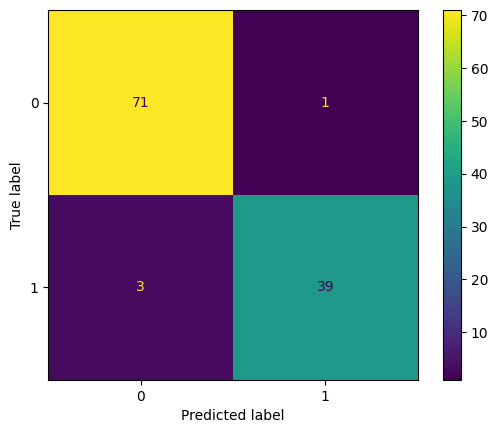

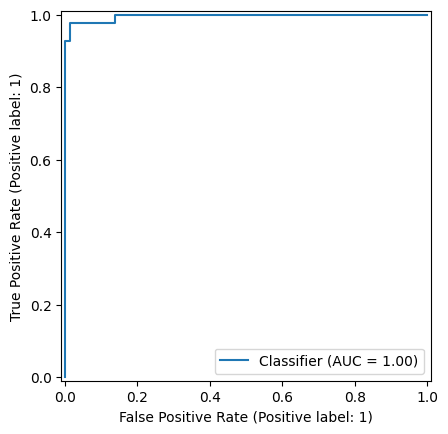

In [17]:
# Final Evaluation
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()


In [18]:
# Save Final Model
joblib.dump(best_pipe, 'best_breast_cancer_model.pkl')
print('Model saved successfully.')


Model saved successfully.


In [19]:
# Prediction Function
def predict_new_patient(new_data):
    '''
    new_data should be a DataFrame with the same feature columns as X.
    '''
    prediction = best_pipe.predict(new_data)
    probability = best_pipe.predict_proba(new_data)[:,1]
    return prediction, probability


In [20]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [21]:
feature_names = joblib.load("feature_names.pkl")

In [22]:
label_mapping = {
    0: "Benign",
    1: "Malignant"
}

joblib.dump(label_mapping, "label_mapping.pkl")

['label_mapping.pkl']

In [24]:
model = joblib.load("best_breast_cancer_model.pkl")

In [27]:
sample = X_test.iloc[[0]]

prediction = best_pipe.predict(sample)[0]
probability = best_pipe.predict_proba(sample)[0]

label = "Malignant" if prediction == 1 else "Benign"

print(f"Predicted Class: {label}")
print(f"Benign Probability: {probability[0]:.2%}")
print(f"Malignant Probability: {probability[1]:.2%}")

Predicted Class: Benign
Benign Probability: 99.96%
Malignant Probability: 0.04%
